# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [3]:
DATA_PATH = "Chicago_Crimes_2012_to_2017.csv"

df = pd.read_csv(DATA_PATH, nrows=50000)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 50000 rows x 23 columns


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,3,10508693,HZ250496,05/03/2016 11:40:00 PM,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)"
1,89,10508695,HZ250409,05/03/2016 09:40:00 PM,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)"
2,197,10508697,HZ250503,05/03/2016 11:31:00 PM,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)"
3,673,10508698,HZ250424,05/03/2016 10:10:00 PM,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)"
4,911,10508699,HZ250455,05/03/2016 10:00:00 PM,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)"


In [4]:
data_source_report = {
    "source": "Kaggle",
    "acquisition_method": "CSV download",
    "date_acquired": "2026-04-16",
    "issues_encountered": [
        "Dataset was large, so only 50,000 rows were loaded for efficiency"
    ]
}
print(data_source_report)

{'source': 'Kaggle', 'acquisition_method': 'CSV download', 'date_acquired': '2026-04-16', 'issues_encountered': ['Dataset was large, so only 50,000 rows were loaded for efficiency']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            50000 non-null  int64  
 1   ID                    50000 non-null  int64  
 2   Case Number           50000 non-null  str    
 3   Date                  50000 non-null  str    
 4   Block                 50000 non-null  str    
 5   IUCR                  50000 non-null  str    
 6   Primary Type          50000 non-null  str    
 7   Description           50000 non-null  str    
 8   Location Description  49918 non-null  str    
 9   Arrest                50000 non-null  bool   
 10  Domestic              50000 non-null  bool   
 11  Beat                  50000 non-null  int64  
 12  District              50000 non-null  float64
 13  Ward                  49999 non-null  float64
 14  Community Area        49985 non-null  float64
 15  FBI Code              50000 no

In [8]:
df.describe()

,Unnamed: 0,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,50000.000000,5.000000e+04,50000.000000,50000.000000,49999.000000,49985.000000,4.374700e+04,4.374700e+04,50000.000000,43747.000000,43747.000000
mean,798520.055920,1.015816e+07,1145.420000,11.222560,22.859077,37.293148,1.164428e+06,1.885511e+06,2015.271900,41.841440,-87.672143
std,123197.118911,5.063125e+05,695.822726,6.950438,13.836990,21.318657,1.660144e+04,3.117195e+04,0.835502,0.085739,0.060426
min,3.000000,2.085900e+04,111.000000,1.000000,1.000000,0.000000,1.094587e+06,1.813910e+06,2012.000000,41.644608,-87.927365
25%,801608.750000,9.926501e+06,612.000000,6.000000,10.000000,23.000000,1.152257e+06,1.858710e+06,2015.000000,41.767740,-87.716397
50%,832584.500000,9.948610e+06,1023.000000,10.000000,23.000000,32.000000,1.166009e+06,1.891853e+06,2015.000000,41.858941,-87.666075
75%,845862.250000,1.052396e+07,1711.000000,17.000000,34.000000,56.000000,1.176417e+06,1.908398e+06,2016.000000,41.904422,-87.627877
max,858419.000000,1.055040e+07,2535.000000,25.000000,50.000000,77.000000,1.204806e+06,1.951523e+06,2016.000000,42.022575,-87.525645


In [6]:
df.describe(include="object")

C:\Users\meeka\AppData\Local\Temp\ipykernel_25504\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,FBI Code,Updated On,Location
count,50000,50000,50000,50000,50000,50000,49918,50000,50000,43747
unique,49995,25977,17306,283,31,266,107,25,205,32795
top,HZ140230,01/18/2015 01:00:00 AM,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,06,08/17/2015 03:03:40 PM,"(41.883500187, -87.627876698)"
freq,5,32,143,4761,10732,5530,11216,10732,25940,95


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

df["Hour"] = df["Date"].dt.hour
df["Day"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month

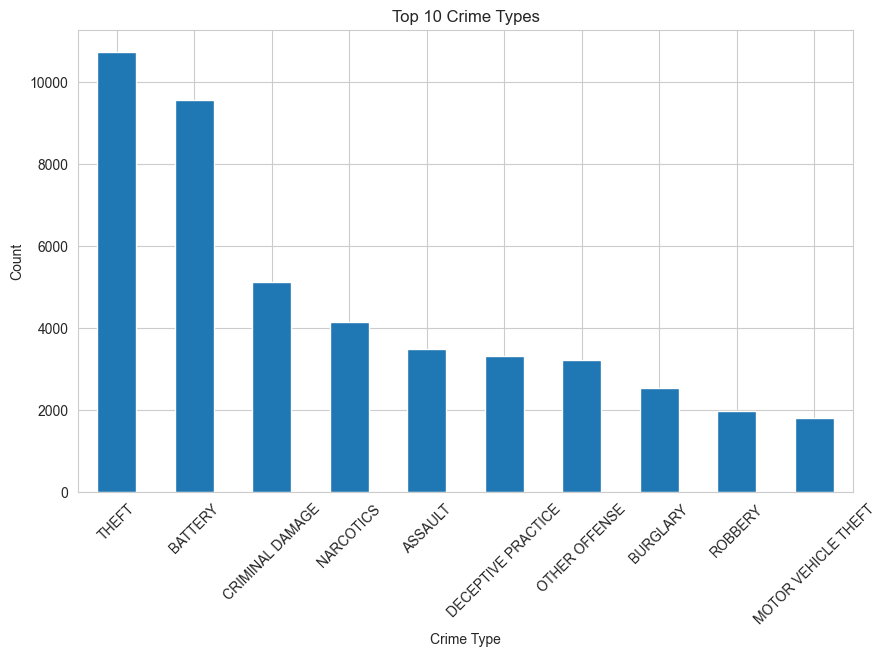

In [7]:
plt.figure(figsize=(10,6))
df["Primary Type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

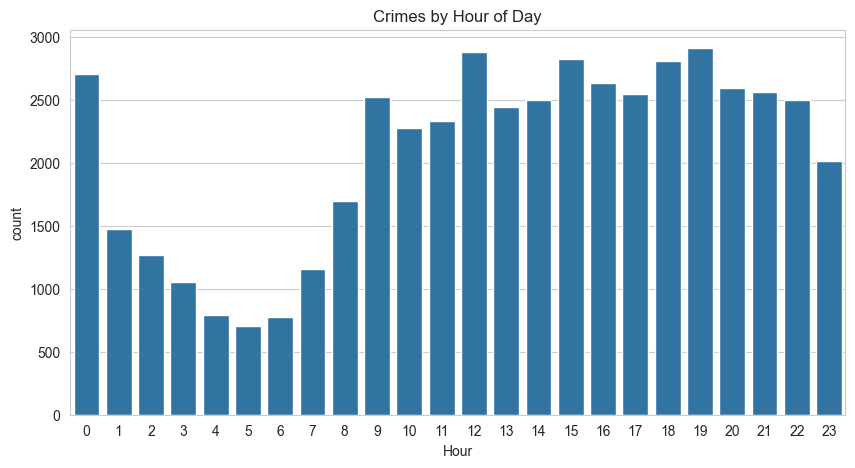

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(x="Hour", data=df)
plt.title("Crimes by Hour of Day")
plt.show()

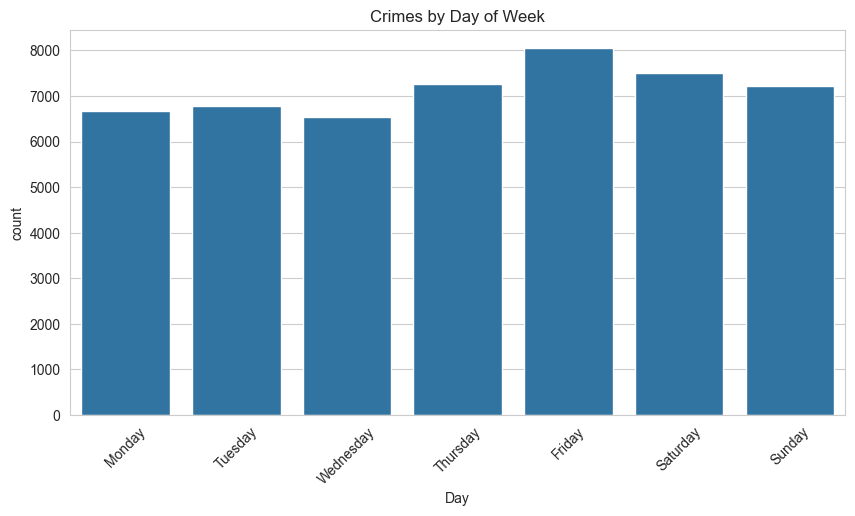

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(
    x="Day",
    data=df,
    order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.title("Crimes by Day of Week")
plt.xticks(rotation=45)
plt.show()

The visualisations show that certain crime types are more frequent than others. Crime activity varies across different hours and days, indicating temporal patterns. These insights will be useful for predictive modeling in later phases.

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [11]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_report = missing_report[missing_report["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print("=== Missing Values Report ===")
print(missing_report)
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
                      Missing Count  Missing %
X Coordinate                   6253     12.506
Longitude                      6253     12.506
Latitude                       6253     12.506
Y Coordinate                   6253     12.506
Location                       6253     12.506
Location Description             82      0.164
Community Area                   15      0.030
Ward                              1      0.002

Total columns with missing values: 8


In [12]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


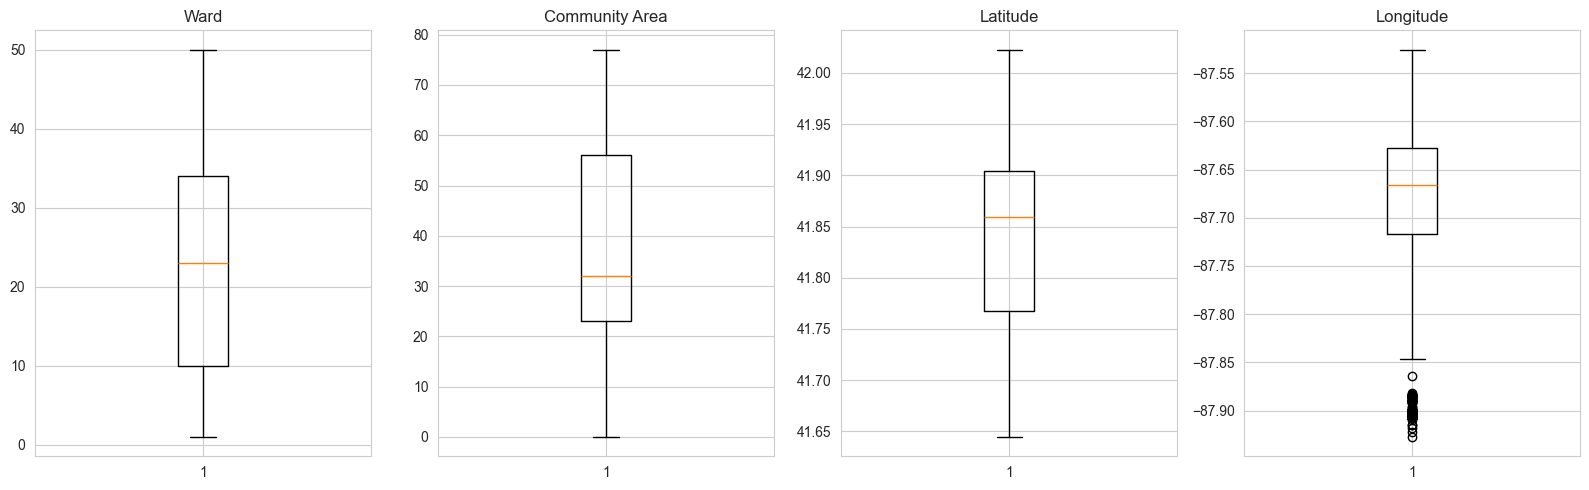

In [13]:
selected_cols = ["Ward", "Community Area", "Latitude", "Longitude"]

fig, axes = plt.subplots(1, len(selected_cols), figsize=(4 * len(selected_cols), 5))
for ax, col in zip(axes, selected_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()